In [1]:
import time
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


SEED = 42


def set_seed(seed=SEED):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)


set_seed()


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


if device.type != "cuda":

    raise RuntimeError(
        "GPU is not active. Enable GPU in Colab."
    )


torch.set_float32_matmul_precision(
    "high"
)


print("Device:", device)

print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

Device: cuda
GPU: Tesla T4


In [2]:
url = (
    "https://raw.githubusercontent.com/"
    "karpathy/char-rnn/master/"
    "data/tinyshakespeare/input.txt"
)


text = urllib.request.urlopen(
    url
).read().decode(
    "utf-8"
)


chars = sorted(
    list(set(text))
)


vocab_size = len(chars)


stoi = {
    ch: i
    for i, ch in enumerate(chars)
}


itos = {
    i: ch
    for i, ch in enumerate(chars)
}


def encode(s):

    return [
        stoi[c]
        for c in s
    ]


def decode(values):

    return "".join(
        itos[i]
        for i in values
    )


data = torch.tensor(
    encode(text),
    dtype=torch.long
)


split = int(
    0.9 * len(data)
)


train_data = data[:split]

val_data = data[split:]


print(
    "Text length:",
    len(text)
)

print(
    "Vocabulary size:",
    vocab_size
)

print(
    "Training characters:",
    len(train_data)
)

print(
    "Validation characters:",
    len(val_data)
)

Text length: 1115394
Vocabulary size: 65
Training characters: 1003854
Validation characters: 111540


In [3]:
BATCH_SIZE = 64

BLOCK_SIZE = 128

EMBED_DIM = 128

N_HEADS = 4

N_LAYERS = 4

DROPOUT = 0.1

TRAIN_STEPS = 600

EVAL_INTERVAL = 100

EVAL_ITERS = 15


def get_batch(
    split_name,
    block_size=BLOCK_SIZE,
    batch_size=BATCH_SIZE
):

    source = (
        train_data
        if split_name == "train"
        else val_data
    )

    positions = torch.randint(
        0,
        len(source)
        - block_size
        - 1,
        (batch_size,)
    )

    x = torch.stack([
        source[
            i:i + block_size
        ]
        for i in positions
    ])

    y = torch.stack([
        source[
            i + 1:
            i + block_size + 1
        ]
        for i in positions
    ])

    return (
        x.to(device),
        y.to(device)
    )


x, y = get_batch(
    "train"
)


print(
    "Input shape:",
    x.shape
)

print(
    "Target shape:",
    y.shape
)

Input shape: torch.Size([64, 128])
Target shape: torch.Size([64, 128])


In [4]:
class CausalSelfAttention(nn.Module):

    def __init__(
        self,
        dim,
        heads,
        max_context,
        dropout
    ):

        super().__init__()

        self.heads = heads

        self.head_dim = (
            dim // heads
        )

        self.qkv = nn.Linear(
            dim,
            3 * dim
        )

        self.projection = nn.Linear(
            dim,
            dim
        )

        self.attention_dropout = (
            nn.Dropout(dropout)
        )

        self.output_dropout = (
            nn.Dropout(dropout)
        )

        mask = torch.tril(
            torch.ones(
                max_context,
                max_context
            )
        )

        self.register_buffer(
            "mask",
            mask.view(
                1,
                1,
                max_context,
                max_context
            )
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        batch_size, length, dim = (
            x.shape
        )

        qkv = self.qkv(x)

        qkv = qkv.view(
            batch_size,
            length,
            3,
            self.heads,
            self.head_dim
        )

        qkv = qkv.permute(
            2,
            0,
            3,
            1,
            4
        )

        q = qkv[0]
        k = qkv[1]
        v = qkv[2]

        scores = (
            q
            @ k.transpose(-2, -1)
        )

        scores = scores / (
            self.head_dim ** 0.5
        )

        scores = scores.masked_fill(
            self.mask[
                :,
                :,
                :length,
                :length
            ] == 0,
            float("-inf")
        )

        weights = F.softmax(
            scores,
            dim=-1
        )

        weights = (
            self.attention_dropout(
                weights
            )
        )

        output = weights @ v

        output = output.transpose(
            1,
            2
        ).contiguous()

        output = output.view(
            batch_size,
            length,
            dim
        )

        output = self.projection(
            output
        )

        output = self.output_dropout(
            output
        )

        if return_attention:

            return output, weights

        return output, None


class FeedForward(nn.Module):

    def __init__(
        self,
        dim,
        dropout
    ):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                dim,
                4 * dim
            ),
            nn.GELU(),
            nn.Linear(
                4 * dim,
                dim
            ),
            nn.Dropout(
                dropout
            )
        )


    def forward(self, x):

        return self.net(x)


class TransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        heads,
        max_context,
        dropout
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(
            dim
        )

        self.norm2 = nn.LayerNorm(
            dim
        )

        self.attention = (
            CausalSelfAttention(
                dim,
                heads,
                max_context,
                dropout
            )
        )

        self.feed_forward = (
            FeedForward(
                dim,
                dropout
            )
        )


    def forward(
        self,
        x,
        return_attention=False
    ):

        attention_output, weights = (
            self.attention(
                self.norm1(x),
                return_attention
            )
        )

        x = x + attention_output

        x = x + self.feed_forward(
            self.norm2(x)
        )

        return x, weights


class SmallGPT(nn.Module):

    def __init__(
        self,
        vocab_size,
        max_context,
        dim=128,
        heads=4,
        layers=4,
        dropout=0.1
    ):

        super().__init__()

        self.max_context = (
            max_context
        )

        self.token_embedding = (
            nn.Embedding(
                vocab_size,
                dim
            )
        )

        self.position_embedding = (
            nn.Embedding(
                max_context,
                dim
            )
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(
                dim,
                heads,
                max_context,
                dropout
            )
            for _ in range(layers)
        ])

        self.final_norm = (
            nn.LayerNorm(dim)
        )

        self.output = nn.Linear(
            dim,
            vocab_size
        )


    def forward(
        self,
        tokens,
        targets=None,
        return_attention=False
    ):

        batch_size, length = (
            tokens.shape
        )

        positions = torch.arange(
            length,
            device=tokens.device
        )

        x = (
            self.token_embedding(
                tokens
            )
            +
            self.position_embedding(
                positions
            )
        )

        attentions = []

        hidden_states = []

        for block in self.blocks:

            x, weights = block(
                x,
                return_attention
            )

            hidden_states.append(x)

            if return_attention:

                attentions.append(
                    weights
                )

        x = self.final_norm(x)

        logits = self.output(x)

        loss = None

        if targets is not None:

            loss = F.cross_entropy(
                logits.reshape(
                    -1,
                    logits.size(-1)
                ),
                targets.reshape(-1)
            )

        return (
            logits,
            loss,
            attentions,
            hidden_states
        )


def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [5]:
set_seed()


gpt_model = SmallGPT(
    vocab_size=vocab_size,
    max_context=BLOCK_SIZE,
    dim=EMBED_DIM,
    heads=N_HEADS,
    layers=N_LAYERS,
    dropout=DROPOUT
).to(device)


print(
    "Layers:",
    N_LAYERS
)

print(
    "Attention heads:",
    N_HEADS
)

print(
    "Embedding dimension:",
    EMBED_DIM
)

print(
    "Context length:",
    BLOCK_SIZE
)

print(
    "Trainable parameters:",
    count_parameters(
        gpt_model
    )
)

Layers: 4
Attention heads: 4
Embedding dimension: 128
Context length: 128
Trainable parameters: 826433


In [6]:
@torch.no_grad()
def estimate_loss(
    model,
    block_size,
    eval_iters=EVAL_ITERS,
    batch_size=BATCH_SIZE
):

    model.eval()

    results = {}

    for split_name in [
        "train",
        "val"
    ]:

        losses = []

        for _ in range(
            eval_iters
        ):

            x, y = get_batch(
                split_name,
                block_size,
                batch_size
            )

            _, loss, _, _ = model(
                x,
                y
            )

            losses.append(
                loss.item()
            )

        results[split_name] = (
            np.mean(losses)
        )

    model.train()

    return results


def train_language_model(
    model,
    block_size,
    steps,
    batch_size,
    eval_interval=100
):

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=0.01
    )

    rows = []

    start = time.perf_counter()

    for step in range(
        1,
        steps + 1
    ):

        model.train()

        x, y = get_batch(
            "train",
            block_size,
            batch_size
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        _, loss, _, _ = model(
            x,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        if (
            step == 1
            or step % eval_interval == 0
            or step == steps
        ):

            losses = estimate_loss(
                model,
                block_size,
                eval_iters=EVAL_ITERS,
                batch_size=batch_size
            )

            rows.append({
                "Step": step,
                "Train Loss":
                    losses["train"],
                "Validation Loss":
                    losses["val"]
            })

            print(
                f"Step {step:03d}/{steps} | "
                f"Train {losses['train']:.4f} | "
                f"Val {losses['val']:.4f}"
            )

    total_time = (
        time.perf_counter()
        - start
    )

    return (
        model,
        pd.DataFrame(rows),
        total_time
    )

In [7]:
set_seed()


(
    gpt_model,
    gpt_history,
    gpt_training_time
) = train_language_model(
    gpt_model,
    block_size=BLOCK_SIZE,
    steps=TRAIN_STEPS,
    batch_size=BATCH_SIZE,
    eval_interval=EVAL_INTERVAL
)


print(
    "Training time:",
    round(
        gpt_training_time / 60,
        2
    ),
    "minutes"
)


gpt_history

Step 001/600 | Train 4.1834 | Val 4.1768
Step 100/600 | Train 2.6232 | Val 2.6185
Step 200/600 | Train 2.5108 | Val 2.5140
Step 300/600 | Train 2.4454 | Val 2.4642
Step 400/600 | Train 2.3902 | Val 2.4014
Step 500/600 | Train 2.3191 | Val 2.3271
Step 600/600 | Train 2.2289 | Val 2.2562
Training time: 0.37 minutes


,Step,Train Loss,Validation Loss
0,1,4.183380,4.176838
1,100,2.623177,2.618524
2,200,2.510778,2.513997
3,300,2.445434,2.464204
4,400,2.390172,2.401416
5,500,2.319062,2.327103
6,600,2.228904,2.256198


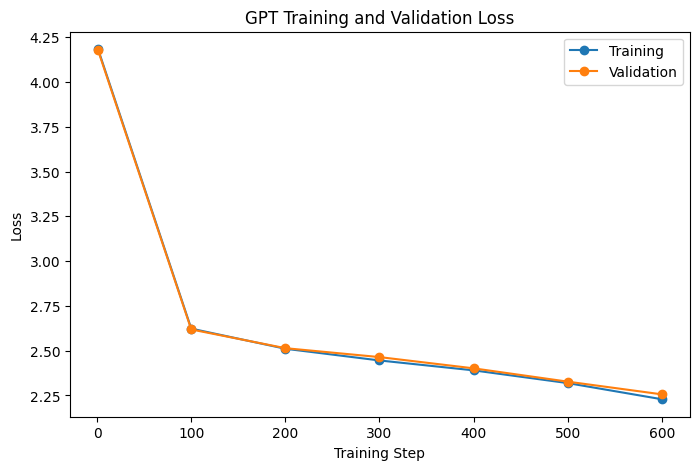

In [8]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    gpt_history["Step"],
    gpt_history["Train Loss"],
    marker="o",
    label="Training"
)

plt.plot(
    gpt_history["Step"],
    gpt_history[
        "Validation Loss"
    ],
    marker="o",
    label="Validation"
)

plt.xlabel("Training Step")

plt.ylabel("Loss")

plt.title(
    "GPT Training and Validation Loss"
)

plt.legend()

plt.show()

In [9]:
@torch.no_grad()
def generate_text(
    model,
    start_tokens,
    new_tokens=400,
    temperature=0.8
):

    model.eval()

    tokens = start_tokens

    for _ in range(
        new_tokens
    ):

        current = tokens[
            :,
            -model.max_context:
        ]

        logits, _, _, _ = model(
            current
        )

        logits = (
            logits[:, -1, :]
            / temperature
        )

        probabilities = F.softmax(
            logits,
            dim=-1
        )

        next_token = (
            torch.multinomial(
                probabilities,
                1
            )
        )

        tokens = torch.cat(
            [
                tokens,
                next_token
            ],
            dim=1
        )

    return tokens


start_text = "ROMEO:"


start_tokens = torch.tensor(
    [
        encode(
            start_text
        )
    ],
    dtype=torch.long,
    device=device
)


generated = generate_text(
    gpt_model,
    start_tokens,
    new_tokens=400
)


print(
    decode(
        generated[0]
        .cpu()
        .tolist()
    )
)

ROMEO:
NI, markeat your thathembe ble on to verin soneer spe ase.

SANIIO: no ghen sid the fo treak will?

For, de whitist al danco ps I panose med thengiss d?

Conond sicosts; Cand he inort whipre ke het ism browid
An ameroure sthing mere toror ap sbey teid ware;
I palitee me nd le my yoford then reime avel t y watheattin oul f f dyomo ise sthe ces brane t?

Turd te de lleeed be Loowoen the sshere ore 


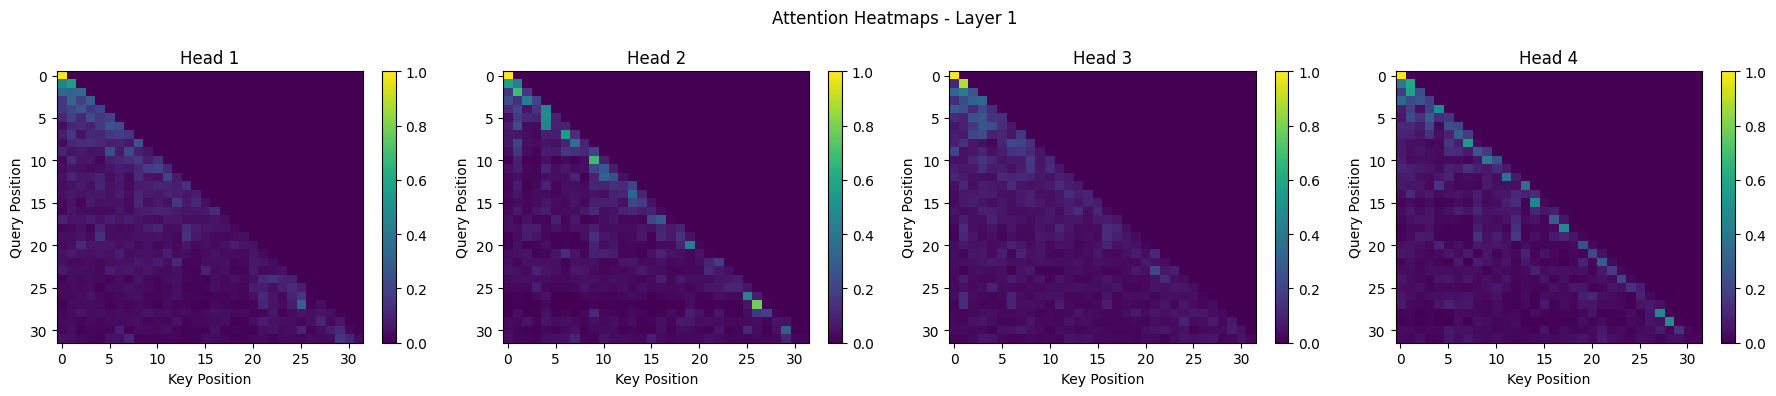

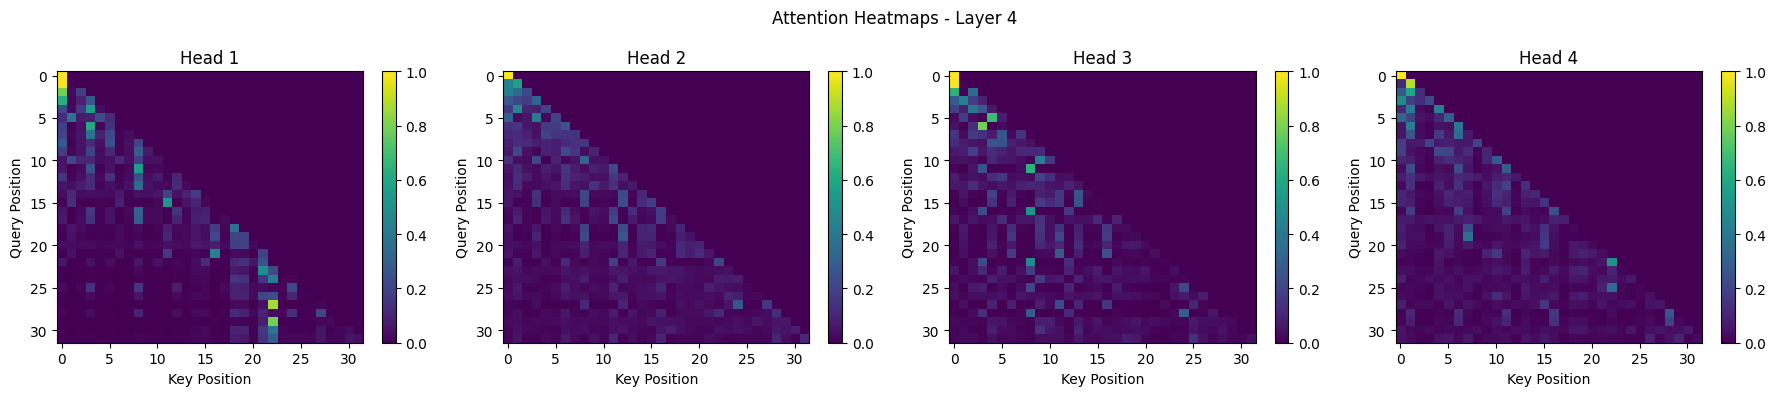

In [10]:
x_attention, _ = get_batch(
    "val",
    block_size=32,
    batch_size=1
)


gpt_model.eval()


with torch.no_grad():

    (
        _,
        _,
        attention_maps,
        _
    ) = gpt_model(
        x_attention,
        return_attention=True
    )


labels = [
    decode([int(value)])
    for value
    in x_attention[0].cpu()
]


labels = [
    "\\n"
    if value == "\n"
    else "_"
    if value == " "
    else value
    for value in labels
]


def show_attention_layer(
    attention,
    layer_number
):

    fig, axes = plt.subplots(
        1,
        N_HEADS,
        figsize=(18, 4)
    )

    for head in range(
        N_HEADS
    ):

        image = axes[
            head
        ].imshow(
            attention[
                0,
                head
            ].cpu(),
            aspect="auto"
        )

        axes[head].set_title(
            f"Head {head + 1}"
        )

        axes[head].set_xlabel(
            "Key Position"
        )

        axes[head].set_ylabel(
            "Query Position"
        )

        fig.colorbar(
            image,
            ax=axes[head]
        )

    fig.suptitle(
        f"Attention Heatmaps - Layer {layer_number}"
    )

    plt.tight_layout()

    plt.show()


show_attention_layer(
    attention_maps[0],
    1
)


show_attention_layer(
    attention_maps[-1],
    4
)

In [11]:
x_stats, _ = get_batch(
    "val",
    block_size=64,
    batch_size=16
)


gpt_model.eval()


with torch.no_grad():

    (
        _,
        _,
        attention_stats,
        _
    ) = gpt_model(
        x_stats,
        return_attention=True
    )


rows = []


for layer_index, attention in enumerate(
    attention_stats
):

    length = attention.size(-1)

    positions = torch.arange(
        length,
        device=device
    )

    distance = (
        positions[:, None]
        - positions[None, :]
    ).abs().float()

    for head in range(
        N_HEADS
    ):

        weights = attention[
            :,
            head
        ]

        mean_distance = (
            weights
            * distance
        ).sum(
            dim=-1
        ).mean().item()

        entropy = (
            -(
                weights.clamp_min(
                    1e-9
                )
                *
                weights.clamp_min(
                    1e-9
                ).log()
            )
            .sum(dim=-1)
            .mean()
            .item()
        )

        self_attention = (
            torch.diagonal(
                weights,
                offset=0,
                dim1=1,
                dim2=2
            )
            .mean()
            .item()
        )

        previous_attention = (
            torch.diagonal(
                weights,
                offset=-1,
                dim1=1,
                dim2=2
            )
            .mean()
            .item()
        )

        rows.append({
            "Layer":
                layer_index + 1,
            "Head":
                head + 1,
            "Mean Attention Distance":
                mean_distance,
            "Attention Entropy":
                entropy,
            "Self Attention":
                self_attention,
            "Previous Token Attention":
                previous_attention
        })


head_statistics = pd.DataFrame(
    rows
)


head_statistics

,Layer,Head,Mean Attention Distance,Attention Entropy,Self Attention,Previous Token Attention
0,1,1,14.594135,3.038259,0.082191,0.084707
1,1,2,13.276671,2.832626,0.082544,0.187888
2,1,3,14.593260,3.044423,0.073296,0.067107
3,1,4,13.745106,2.849470,0.078675,0.183743
4,2,1,7.467994,2.461790,0.100245,0.203554
5,2,2,8.523263,2.608120,0.099985,0.185750
6,2,3,7.481506,2.425014,0.099487,0.244219
7,2,4,9.937443,2.516163,0.110755,0.121150
8,3,1,11.259348,2.569336,0.092665,0.104692
9,3,2,8.962164,2.527886,0.111765,0.151356


In [12]:
CONTEXT_LENGTHS = [
    32,
    64,
    128
]


CONTEXT_STEPS = 200


def context_experiment(
    context_length
):

    set_seed()

    model = SmallGPT(
        vocab_size=vocab_size,
        max_context=context_length,
        dim=EMBED_DIM,
        heads=N_HEADS,
        layers=N_LAYERS,
        dropout=DROPOUT
    ).to(device)

    if device.type == "cuda":

        torch.cuda.reset_peak_memory_stats()

    (
        model,
        history,
        total_time
    ) = train_language_model(
        model,
        block_size=context_length,
        steps=CONTEXT_STEPS,
        batch_size=32,
        eval_interval=100
    )

    final_loss = estimate_loss(
        model,
        context_length,
        eval_iters=20,
        batch_size=32
    )["val"]

    perplexity = np.exp(
        final_loss
    )

    peak_memory = 0

    if device.type == "cuda":

        peak_memory = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )

    result = {
        "Context Length":
            context_length,
        "Validation Loss":
            final_loss,
        "Perplexity":
            perplexity,
        "Seconds per Step":
            total_time
            / CONTEXT_STEPS,
        "Peak GPU Memory MB":
            peak_memory,
        "Parameters":
            count_parameters(
                model
            )
    }

    del model

    torch.cuda.empty_cache()

    return result

In [13]:
context_rows = []


for context_length in (
    CONTEXT_LENGTHS
):

    print(
        "\nContext length:",
        context_length
    )

    result = context_experiment(
        context_length
    )

    context_rows.append(
        result
    )


context_results = pd.DataFrame(
    context_rows
)


context_results


Context length: 32
Step 001/200 | Train 4.1918 | Val 4.2042
Step 100/200 | Train 2.6250 | Val 2.6094
Step 200/200 | Train 2.4583 | Val 2.4803

Context length: 64
Step 001/200 | Train 4.1899 | Val 4.1905
Step 100/200 | Train 2.6502 | Val 2.6375
Step 200/200 | Train 2.5101 | Val 2.5166

Context length: 128
Step 001/200 | Train 4.1872 | Val 4.1781
Step 100/200 | Train 2.6415 | Val 2.6307
Step 200/200 | Train 2.5188 | Val 2.5203


,Context Length,Validation Loss,Perplexity,Seconds per Step,Peak GPU Memory MB,Parameters
0,32,2.481048,11.953791,0.014879,81.597656,814145
1,64,2.510472,12.310745,0.013845,133.531250,818241
2,128,2.515185,12.368897,0.025237,261.891113,826433


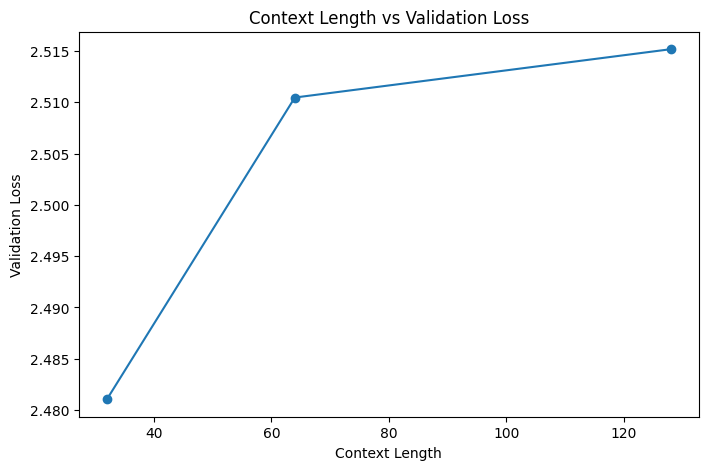

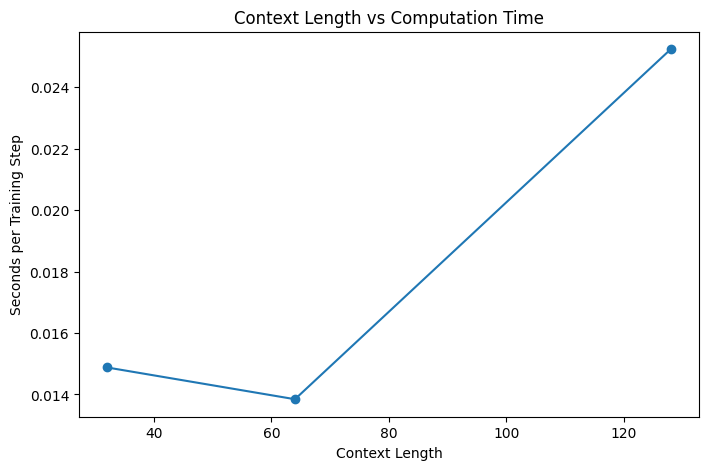

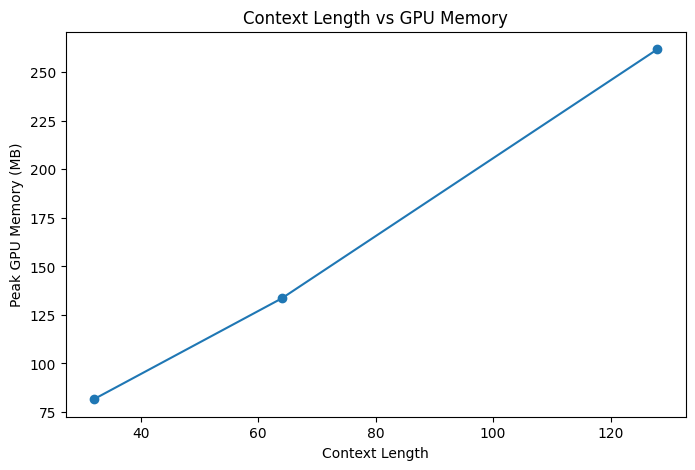

In [14]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    context_results[
        "Context Length"
    ],
    context_results[
        "Validation Loss"
    ],
    marker="o"
)

plt.xlabel(
    "Context Length"
)

plt.ylabel(
    "Validation Loss"
)

plt.title(
    "Context Length vs Validation Loss"
)

plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    context_results[
        "Context Length"
    ],
    context_results[
        "Seconds per Step"
    ],
    marker="o"
)

plt.xlabel(
    "Context Length"
)

plt.ylabel(
    "Seconds per Training Step"
)

plt.title(
    "Context Length vs Computation Time"
)

plt.show()


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    context_results[
        "Context Length"
    ],
    context_results[
        "Peak GPU Memory MB"
    ],
    marker="o"
)

plt.xlabel(
    "Context Length"
)

plt.ylabel(
    "Peak GPU Memory (MB)"
)

plt.title(
    "Context Length vs GPU Memory"
)

plt.show()

In [15]:
digits = load_digits()


images = torch.tensor(
    digits.images,
    dtype=torch.float32
).unsqueeze(1)


images = images / 16.0


labels = torch.tensor(
    digits.target,
    dtype=torch.long
)


indices = np.arange(
    len(images)
)


train_indices, test_indices = (
    train_test_split(
        indices,
        test_size=0.2,
        random_state=SEED,
        stratify=digits.target
    )
)


train_indices = torch.tensor(
    train_indices,
    dtype=torch.long
)


test_indices = torch.tensor(
    test_indices,
    dtype=torch.long
)


patch_train_loader = DataLoader(
    TensorDataset(
        images[train_indices],
        labels[train_indices]
    ),
    batch_size=128,
    shuffle=True
)


patch_test_loader = DataLoader(
    TensorDataset(
        images[test_indices],
        labels[test_indices]
    ),
    batch_size=128,
    shuffle=False
)


print(
    "Training images:",
    len(train_indices)
)

print(
    "Test images:",
    len(test_indices)
)

print(
    "Image shape:",
    images.shape[1:]
)

Training images: 1437
Test images: 360
Image shape: torch.Size([1, 8, 8])


In [16]:
class PatchTransformer(nn.Module):

    def __init__(
        self,
        dim=128,
        heads=4,
        layers=4
    ):

        super().__init__()

        self.patch_embedding = (
            nn.Conv2d(
                1,
                dim,
                kernel_size=2,
                stride=2
            )
        )

        self.position_embedding = (
            nn.Parameter(
                torch.zeros(
                    1,
                    16,
                    dim
                )
            )
        )

        nn.init.normal_(
            self.position_embedding,
            mean=0.0,
            std=0.02
        )

        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=dim,
                nhead=heads,
                dim_feedforward=4 * dim,
                dropout=0.1,
                batch_first=True
            )
            for _ in range(
                layers
            )
        ])

        self.norm = nn.LayerNorm(
            dim
        )

        self.classifier = nn.Linear(
            dim,
            10
        )


    def forward(
        self,
        images,
        use_position=True,
        return_hidden=False
    ):

        content = (
            self.patch_embedding(
                images
            )
            .flatten(2)
            .transpose(1, 2)
        )

        if use_position:

            x = (
                content
                +
                self.position_embedding
            )

        else:

            x = content

        hidden_states = []

        for layer in self.layers:

            x = layer(x)

            hidden_states.append(x)

        output = self.norm(x)

        logits = self.classifier(
            output.mean(dim=1)
        )

        if return_hidden:

            return (
                logits,
                content,
                hidden_states
            )

        return logits

In [21]:
set_seed()


patch_model = PatchTransformer(
    dim=128,
    heads=4,
    layers=4
).to(device)


optimizer = torch.optim.AdamW(
    patch_model.parameters(),
    lr=0.001
)


criterion = nn.CrossEntropyLoss()


def patch_accuracy(
    model,
    loader
):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            y = y.to(device)

            output = model(x)

            prediction = (
                output.argmax(dim=1)
            )

            correct += (
                prediction == y
            ).sum().item()

            total += y.size(0)

    return (
        correct / total
    )


PATCH_EPOCHS = 25


for epoch in range(
    1,
    PATCH_EPOCHS + 1
):

    patch_model.train()

    losses = []

    for x, y in (
        patch_train_loader
    ):

        x = x.to(device)

        y = y.to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        output = patch_model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    accuracy = patch_accuracy(
        patch_model,
        patch_test_loader
    )

    print(
        f"Epoch {epoch:02d}/{PATCH_EPOCHS} | "
        f"Loss {np.mean(losses):.4f} | "
        f"Test Accuracy {accuracy:.4f}"
    )

Epoch 01/25 | Loss 2.4885 | Test Accuracy 0.1000
Epoch 02/25 | Loss 2.3308 | Test Accuracy 0.1028
Epoch 03/25 | Loss 2.3318 | Test Accuracy 0.1000
Epoch 04/25 | Loss 2.3268 | Test Accuracy 0.1056
Epoch 05/25 | Loss 2.3143 | Test Accuracy 0.1000
Epoch 06/25 | Loss 2.2800 | Test Accuracy 0.2194
Epoch 07/25 | Loss 2.0597 | Test Accuracy 0.2194
Epoch 08/25 | Loss 1.8440 | Test Accuracy 0.2583
Epoch 09/25 | Loss 1.7129 | Test Accuracy 0.4639
Epoch 10/25 | Loss 1.4860 | Test Accuracy 0.4528
Epoch 11/25 | Loss 1.2092 | Test Accuracy 0.6917
Epoch 12/25 | Loss 0.9091 | Test Accuracy 0.7389
Epoch 13/25 | Loss 0.7186 | Test Accuracy 0.7917
Epoch 14/25 | Loss 0.5646 | Test Accuracy 0.8083
Epoch 15/25 | Loss 0.5228 | Test Accuracy 0.8167
Epoch 16/25 | Loss 0.4237 | Test Accuracy 0.9056
Epoch 17/25 | Loss 0.3168 | Test Accuracy 0.9167
Epoch 18/25 | Loss 0.2612 | Test Accuracy 0.9194
Epoch 19/25 | Loss 0.2136 | Test Accuracy 0.9333
Epoch 20/25 | Loss 0.1464 | Test Accuracy 0.9528
Epoch 21/25 | Loss 0

In [22]:
@torch.no_grad()
def measure_locality(
    model,
    loader,
    use_position
):

    model.eval()

    layer_results = {
        i: {
            "same": [],
            "top_left": [],
            "diagonal": [],
            "other": []
        }
        for i in range(4)
    }

    for batch_index, (
        x,
        _
    ) in enumerate(loader):

        if batch_index >= 3:
            break

        x = x.to(device)

        (
            _,
            content,
            hidden_states
        ) = model(
            x,
            use_position=use_position,
            return_hidden=True
        )

        content = F.normalize(
            content,
            dim=-1
        )

        batch_size = (
            content.size(0)
        )

        number_of_patches = (
            content.size(1)
        )

        targets = torch.arange(
            number_of_patches,
            device=device
        ).unsqueeze(0).expand(
            batch_size,
            -1
        )

        for layer_index, hidden in enumerate(
            hidden_states
        ):

            hidden = F.normalize(
                hidden,
                dim=-1
            )

            similarities = (
                hidden
                @ content.transpose(
                    1,
                    2
                )
            )

            predicted = (
                similarities.argmax(
                    dim=-1
                )
            )

            same_accuracy = (
                predicted
                .eq(targets)
                .float()
                .mean()
                .item()
            )

            top_left_accuracy = (
                predicted[:, 0]
                .eq(0)
                .float()
                .mean()
                .item()
            )

            diagonal = (
                torch.diagonal(
                    similarities,
                    dim1=1,
                    dim2=2
                )
                .mean()
                .item()
            )

            diagonal_sum = (
                torch.diagonal(
                    similarities,
                    dim1=1,
                    dim2=2
                )
                .sum()
            )

            other = (
                (
                    similarities.sum()
                    - diagonal_sum
                )
                /
                (
                    batch_size
                    * number_of_patches
                    * (
                        number_of_patches
                        - 1
                    )
                )
            ).item()

            layer_results[
                layer_index
            ]["same"].append(
                same_accuracy
            )

            layer_results[
                layer_index
            ]["top_left"].append(
                top_left_accuracy
            )

            layer_results[
                layer_index
            ]["diagonal"].append(
                diagonal
            )

            layer_results[
                layer_index
            ]["other"].append(
                other
            )

    rows = []

    for layer_index in range(4):

        rows.append({
            "Position Encoding":
                "On"
                if use_position
                else "Off",
            "Layer":
                layer_index + 1,
            "Same Patch Retrieval":
                np.mean(
                    layer_results[
                        layer_index
                    ]["same"]
                ),
            "Top Left Retrieval":
                np.mean(
                    layer_results[
                        layer_index
                    ]["top_left"]
                ),
            "Same Patch Similarity":
                np.mean(
                    layer_results[
                        layer_index
                    ]["diagonal"]
                ),
            "Other Patch Similarity":
                np.mean(
                    layer_results[
                        layer_index
                    ]["other"]
                )
        })

    return rows


locality_rows = (
    measure_locality(
        patch_model,
        patch_test_loader,
        True
    )
    +
    measure_locality(
        patch_model,
        patch_test_loader,
        False
    )
)


locality_results = pd.DataFrame(
    locality_rows
)


locality_results

,Position Encoding,Layer,Same Patch Retrieval,Top Left Retrieval,Same Patch Similarity,Other Patch Similarity
0,On,1,0.611003,0.834936,0.815531,0.538128
1,On,2,0.527181,0.607171,0.504011,0.287064
2,On,3,0.453563,0.412460,0.235571,0.108029
3,On,4,0.212790,0.188301,0.054086,0.006980
4,Off,1,0.695788,0.918470,0.896172,0.604921
5,Off,2,0.624124,0.798678,0.645630,0.382073
6,Off,3,0.593111,0.734375,0.411953,0.222316
7,Off,4,0.475536,0.510216,0.202728,0.096144


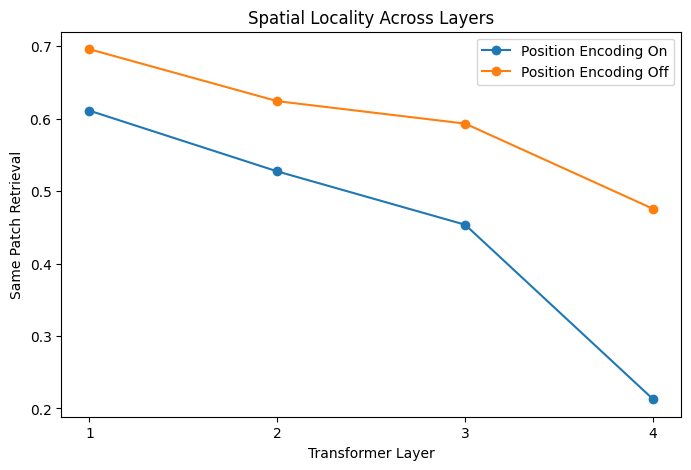

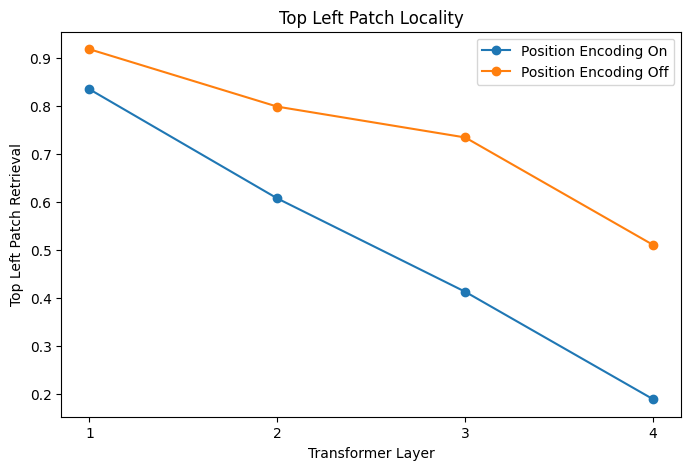

In [23]:
plt.figure(
    figsize=(8, 5)
)


for state in [
    "On",
    "Off"
]:

    values = locality_results[
        locality_results[
            "Position Encoding"
        ] == state
    ]

    plt.plot(
        values["Layer"],
        values[
            "Same Patch Retrieval"
        ],
        marker="o",
        label=f"Position Encoding {state}"
    )


plt.xlabel(
    "Transformer Layer"
)

plt.ylabel(
    "Same Patch Retrieval"
)

plt.title(
    "Spatial Locality Across Layers"
)

plt.xticks(
    [1, 2, 3, 4]
)

plt.legend()

plt.show()


plt.figure(
    figsize=(8, 5)
)


for state in [
    "On",
    "Off"
]:

    values = locality_results[
        locality_results[
            "Position Encoding"
        ] == state
    ]

    plt.plot(
        values["Layer"],
        values[
            "Top Left Retrieval"
        ],
        marker="o",
        label=f"Position Encoding {state}"
    )


plt.xlabel(
    "Transformer Layer"
)

plt.ylabel(
    "Top Left Patch Retrieval"
)

plt.title(
    "Top Left Patch Locality"
)

plt.xticks(
    [1, 2, 3, 4]
)

plt.legend()

plt.show()

In [20]:
final_summary = pd.DataFrame([
    {
        "Experiment":
            "GPT Language Model",
        "Value":
            gpt_history[
                "Validation Loss"
            ].iloc[-1]
    },
    {
        "Experiment":
            "Context 32 Validation Loss",
        "Value":
            context_results.loc[
                context_results[
                    "Context Length"
                ] == 32,
                "Validation Loss"
            ].iloc[0]
    },
    {
        "Experiment":
            "Context 64 Validation Loss",
        "Value":
            context_results.loc[
                context_results[
                    "Context Length"
                ] == 64,
                "Validation Loss"
            ].iloc[0]
    },
    {
        "Experiment":
            "Context 128 Validation Loss",
        "Value":
            context_results.loc[
                context_results[
                    "Context Length"
                ] == 128,
                "Validation Loss"
            ].iloc[0]
    }
])


final_summary

,Experiment,Value
0,GPT Language Model,2.256198
1,Context 32 Validation Loss,2.481048
2,Context 64 Validation Loss,2.510472
3,Context 128 Validation Loss,2.515185
